# 08 — Segmentation Analysis

**Objective:** Segment drivers and customers into distinct groups to direct specific actions.

**Analyses:**
1. **Driver Segmentation** (K-Means) — operational risk profiles
2. **Customer Segmentation** (K-Means) — purchasing behavior profiles
3. **Priority Matrix** — where to focus resources for maximum impact

> Segmentation enables personalized actions that are more efficient and yield higher ROI than generic treatments.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

master = pd.read_parquet('../data/processed/master.parquet')
sns.set_theme(style='whitegrid')
print(f'Dataset: {master.shape[0]:,} orders')

Dataset: 10,000 orders


## 1. Driver Segmentation

**Features used:**
- `missing_rate` — failure rate
- `total_deliveries` — work volume
- `avg_order_value` — average ticket value of fulfilled orders
- `region_diversity` — number of regions served

  File "C:\Users\d_men\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\d_men\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\d_men\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\d_men\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


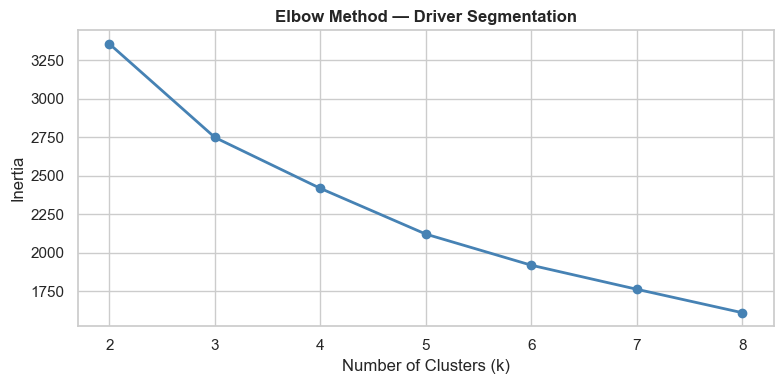

In [2]:
driver_profile = (
    master.groupby('driver_id')
    .agg(
        total_deliveries=('order_id', 'count'),
        missing_rate=('has_missing', 'mean'),
        avg_order_value=('order_amount', 'mean'),
        region_diversity=('region', 'nunique'),
        avg_items=('items_delivered', 'mean'),
    )
    .reset_index()
)
driver_profile = driver_profile[driver_profile['total_deliveries'] >= 3]

feats_d = ['missing_rate', 'total_deliveries', 'avg_order_value', 'region_diversity', 'avg_items']
X_d = driver_profile[feats_d].fillna(0)

scaler_d = StandardScaler()
X_d_sc = scaler_d.fit_transform(X_d)

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_d_sc)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
ax.set_title('Elbow Method — Driver Segmentation', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig('../reports/figures/21_driver_elbow.png', dpi=150)
plt.show()

,n_drivers,avg_missing_rate,avg_deliveries,avg_ticket,profile
cluster,,,,,
0,419,0.000,6.556,277.066,Low Risk
2,404,0.001,6.545,259.983,Medium Risk
1,424,0.325,10.870,299.905,High Risk


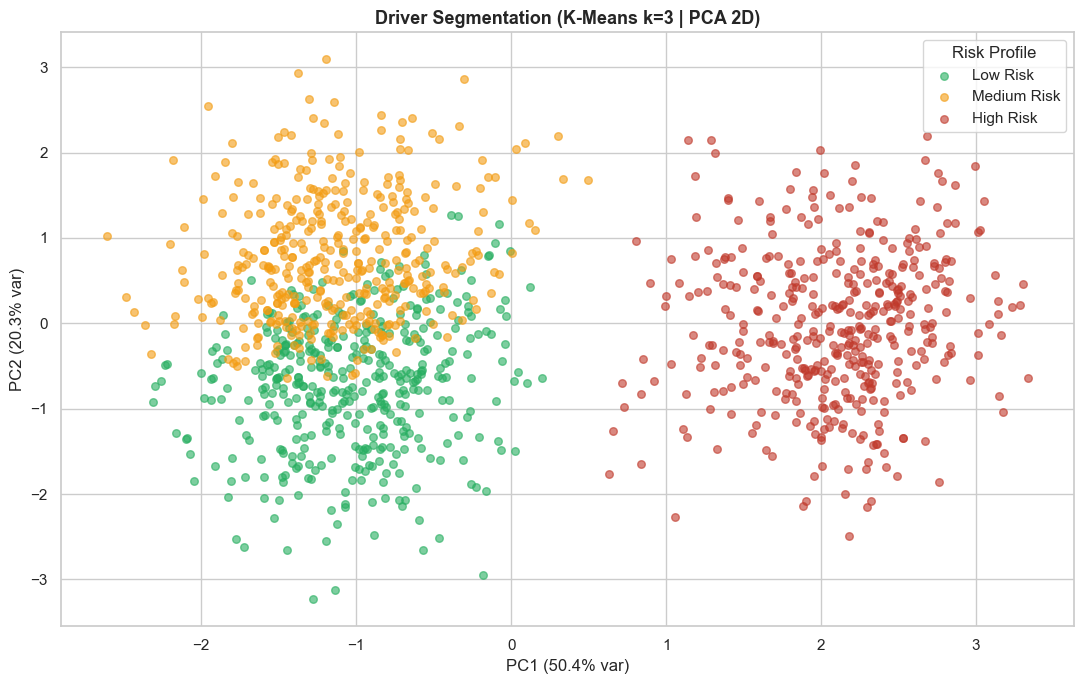


Driver distribution by profile:
  High Risk: 424 drivers (34.0%) | Average rate: 32.5%
  Low Risk: 419 drivers (33.6%) | Average rate: 0.0%
  Medium Risk: 404 drivers (32.4%) | Average rate: 0.1%


In [3]:
# Apply with k=3 (3 profiles: high/medium/low risk)
km_d = KMeans(n_clusters=3, random_state=42, n_init=10)
driver_profile['cluster'] = km_d.fit_predict(X_d_sc)

cluster_summary = (
    driver_profile.groupby('cluster')
    .agg(
        n_drivers=('driver_id', 'count'),
        avg_missing_rate=('missing_rate', 'mean'),
        avg_deliveries=('total_deliveries', 'mean'),
        avg_ticket=('avg_order_value', 'mean'),
    )
    .round(3)
)

# Name clusters by failure rate
cluster_summary = cluster_summary.sort_values('avg_missing_rate')
cluster_summary['profile'] = ['Low Risk', 'Medium Risk', 'High Risk']

display(cluster_summary)

# Map label back
label_map = cluster_summary['profile'].to_dict()
ordered_clusters = cluster_summary.index.tolist()
driver_profile['profile'] = driver_profile['cluster'].map(label_map)

# Visualization — scatter with PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_d_sc)
driver_profile['pca1'] = coords[:, 0]
driver_profile['pca2'] = coords[:, 1]

colors_map = {'Low Risk': '#27ae60', 'Medium Risk': '#f39c12', 'High Risk': '#c0392b'}

fig, ax = plt.subplots(figsize=(11, 7))
for profile, color in colors_map.items():
    subset = driver_profile[driver_profile['profile'] == profile]
    ax.scatter(subset['pca1'], subset['pca2'], c=color, label=profile, alpha=0.6, s=30)

ax.set_title('Driver Segmentation (K-Means k=3 | PCA 2D)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend(title='Risk Profile', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/22_driver_clusters.png', dpi=150)
plt.show()

print(f"\nDriver distribution by profile:")
for profile, grp in driver_profile.groupby('profile'):
    pct = len(grp) / len(driver_profile) * 100
    print(f"  {profile}: {len(grp)} drivers ({pct:.1f}%) | Average rate: {grp['missing_rate'].mean()*100:.1f}%")

## 2. Customer Segmentation

**Features used:**
- `total_orders` — purchase frequency
- `total_spent` — total amount spent
- `avg_order_value` — average ticket value
- `missing_rate` — frequency of issues received

,n_customers,avg_orders,avg_spent,avg_ticket,avg_missing,avg_age,segment
cluster,,,,,,,
3,340,11.40,3474.33,308.31,0.14,53.40,VIP
1,220,6.27,2057.77,331.05,0.34,54.78,Regular High
2,355,6.90,1771.09,260.89,0.09,73.08,Regular Low
0,324,7.08,1760.19,251.01,0.10,34.81,Occasional


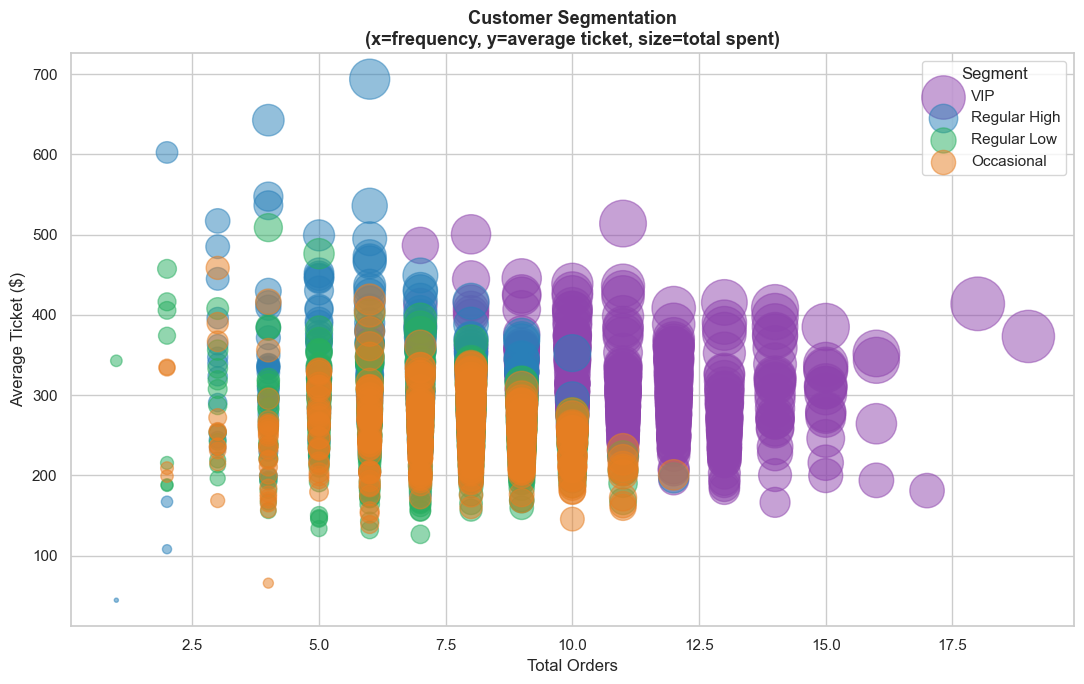

In [4]:
customer_profile = (
    master.groupby('customer_id')
    .agg(
        total_orders=('order_id', 'count'),
        total_spent=('order_amount', 'sum'),
        avg_order_value=('order_amount', 'mean'),
        missing_rate=('has_missing', 'mean'),
        customer_age=('customer_age', 'first'),
    )
    .reset_index()
)

feats_c = ['total_orders', 'total_spent', 'avg_order_value', 'missing_rate', 'customer_age']
X_c = customer_profile[feats_c].fillna(0)

scaler_c = StandardScaler()
X_c_sc = scaler_c.fit_transform(X_c)

km_c = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_profile['cluster'] = km_c.fit_predict(X_c_sc)

cust_summary = (
    customer_profile.groupby('cluster')
    .agg(
        n_customers=('customer_id', 'count'),
        avg_orders=('total_orders', 'mean'),
        avg_spent=('total_spent', 'mean'),
        avg_ticket=('avg_order_value', 'mean'),
        avg_missing=('missing_rate', 'mean'),
        avg_age=('customer_age', 'mean'),
    )
    .round(2)
    .sort_values('avg_spent', ascending=False)
)

# Name clusters
cust_summary['segment'] = ['VIP', 'Regular High', 'Regular Low', 'Occasional']
display(cust_summary)

label_map_c = cust_summary['segment'].to_dict()
customer_profile['segment'] = customer_profile['cluster'].map(label_map_c)

# Visualization: bubble chart — frequency x average ticket, size = total spent
fig, ax = plt.subplots(figsize=(11, 7))
seg_colors = {'VIP': '#8e44ad', 'Regular High': '#2980b9', 'Regular Low': '#27ae60', 'Occasional': '#e67e22'}

for seg, color in seg_colors.items():
    s = customer_profile[customer_profile['segment'] == seg]
    ax.scatter(s['total_orders'], s['avg_order_value'],
               s=s['total_spent'] / 5, c=color, alpha=0.5, label=seg)

ax.set_title('Customer Segmentation\n(x=frequency, y=average ticket, size=total spent)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Orders')
ax.set_ylabel('Average Ticket ($)')
ax.legend(title='Segment', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/23_customer_segments.png', dpi=150)
plt.show()

## 3. Priority Matrix — Financial Impact by Driver Segment

ESTIMATED FINANCIAL IMPACT BY DRIVER SEGMENT
(Estimated cost per failure: $25)



,driver_profile,total_orders,total_failures,failure_rate,estimated_cost,pct_revenue_at_risk
0,High Risk,4609,1499,32.5%,"$37,475",2.71%
1,Low Risk,2747,0,0.0%,$0,0.0%
2,Medium Risk,2644,3,0.1%,$75,0.01%



Total estimated cost of failures: $37,550
Cost attributable to High Risk drivers: $37,475 (99.8% of total)


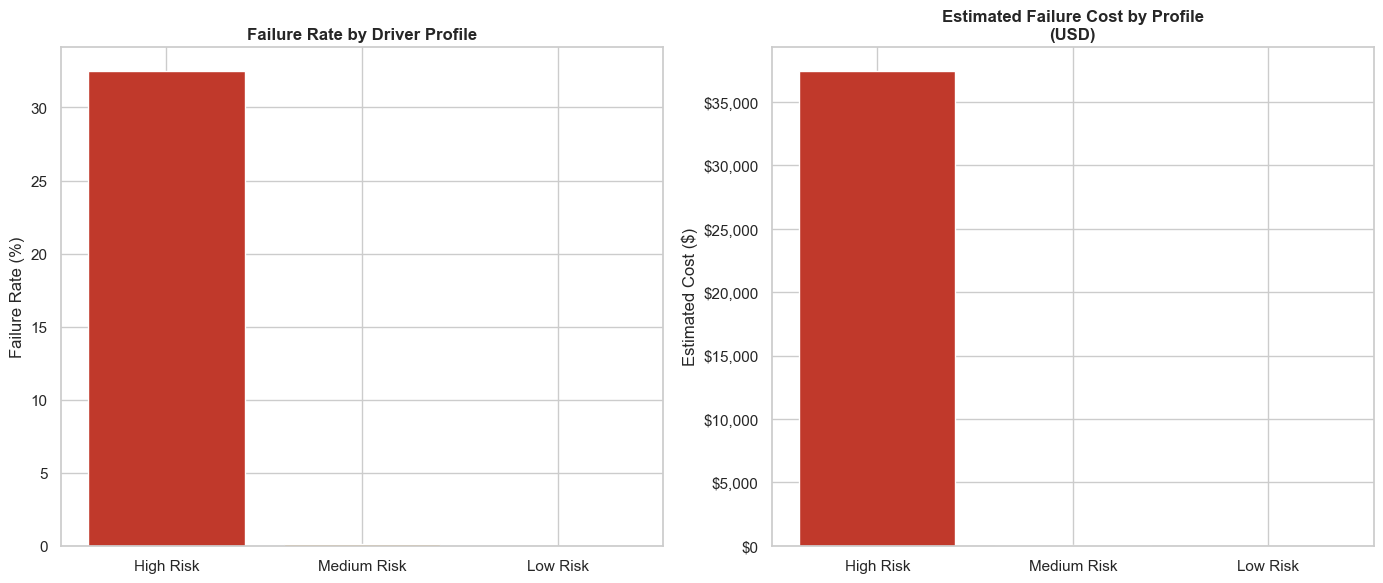

In [5]:
# Estimate financial impact: each failure = redelivery cost + item loss (~$25 estimated)
COST_PER_FAILURE = 25  # estimated USD per delivery with issue

# Join driver profile back to master
perf_map = driver_profile.set_index('driver_id')['profile'].to_dict()
master['driver_profile'] = master['driver_id'].map(perf_map)

impact = (
    master.groupby('driver_profile')
    .agg(
        total_orders=('order_id', 'count'),
        total_failures=('has_missing', 'sum'),
        failure_rate=('has_missing', 'mean'),
        total_revenue=('order_amount', 'sum'),
    )
    .reset_index()
)
impact['estimated_cost'] = impact['total_failures'] * COST_PER_FAILURE
impact['pct_revenue_at_risk'] = impact['estimated_cost'] / impact['total_revenue'] * 100

print('ESTIMATED FINANCIAL IMPACT BY DRIVER SEGMENT')
print(f'(Estimated cost per failure: ${COST_PER_FAILURE})')
print()
display(impact[['driver_profile', 'total_orders', 'total_failures',
                'failure_rate', 'estimated_cost', 'pct_revenue_at_risk']]
        .assign(
            failure_rate=lambda d: (d['failure_rate']*100).round(1).astype(str)+'%',
            estimated_cost=lambda d: d['estimated_cost'].apply(lambda x: f'${x:,.0f}'),
            pct_revenue_at_risk=lambda d: d['pct_revenue_at_risk'].round(2).astype(str)+'%'
        ))

total_cost = impact['estimated_cost'].sum()
high_risk_cost = impact[impact['driver_profile'] == 'High Risk']['estimated_cost'].sum()
print(f"\nTotal estimated cost of failures: ${total_cost:,.0f}")
print(f"Cost attributable to High Risk drivers: ${high_risk_cost:,.0f} ({high_risk_cost/total_cost*100:.1f}% of total)")

# Impact chart
order_seg = ['High Risk', 'Medium Risk', 'Low Risk']
impact_ordered = impact.set_index('driver_profile').reindex(order_seg).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_seg = ['#c0392b', '#f39c12', '#27ae60']

axes[0].bar(impact_ordered['driver_profile'], impact_ordered['failure_rate']*100, color=colors_seg)
axes[0].set_title('Failure Rate by Driver Profile', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Failure Rate (%)')

axes[1].bar(impact_ordered['driver_profile'], impact_ordered['estimated_cost'], color=colors_seg)
axes[1].set_title('Estimated Failure Cost by Profile\n(USD)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Estimated Cost ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../reports/figures/24_financial_impact_by_segment.png', dpi=150)
plt.show()